## **2. Inference**

/tmp/ipykernel_267765/1107753839.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.bar(x, risks, alpha=0.8, ecolor='black', capsize=4, color=plt.cm.get_cmap('viridis')(i/n_datasets))
/tmp/ipykernel_267765/1107753839.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.bar(x, risks, alpha=0.8, ecolor='black', capsize=4, color=plt.cm.get_cmap('viridis')(i/n_datasets))
/tmp/ipykernel_267765/1107753839.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax

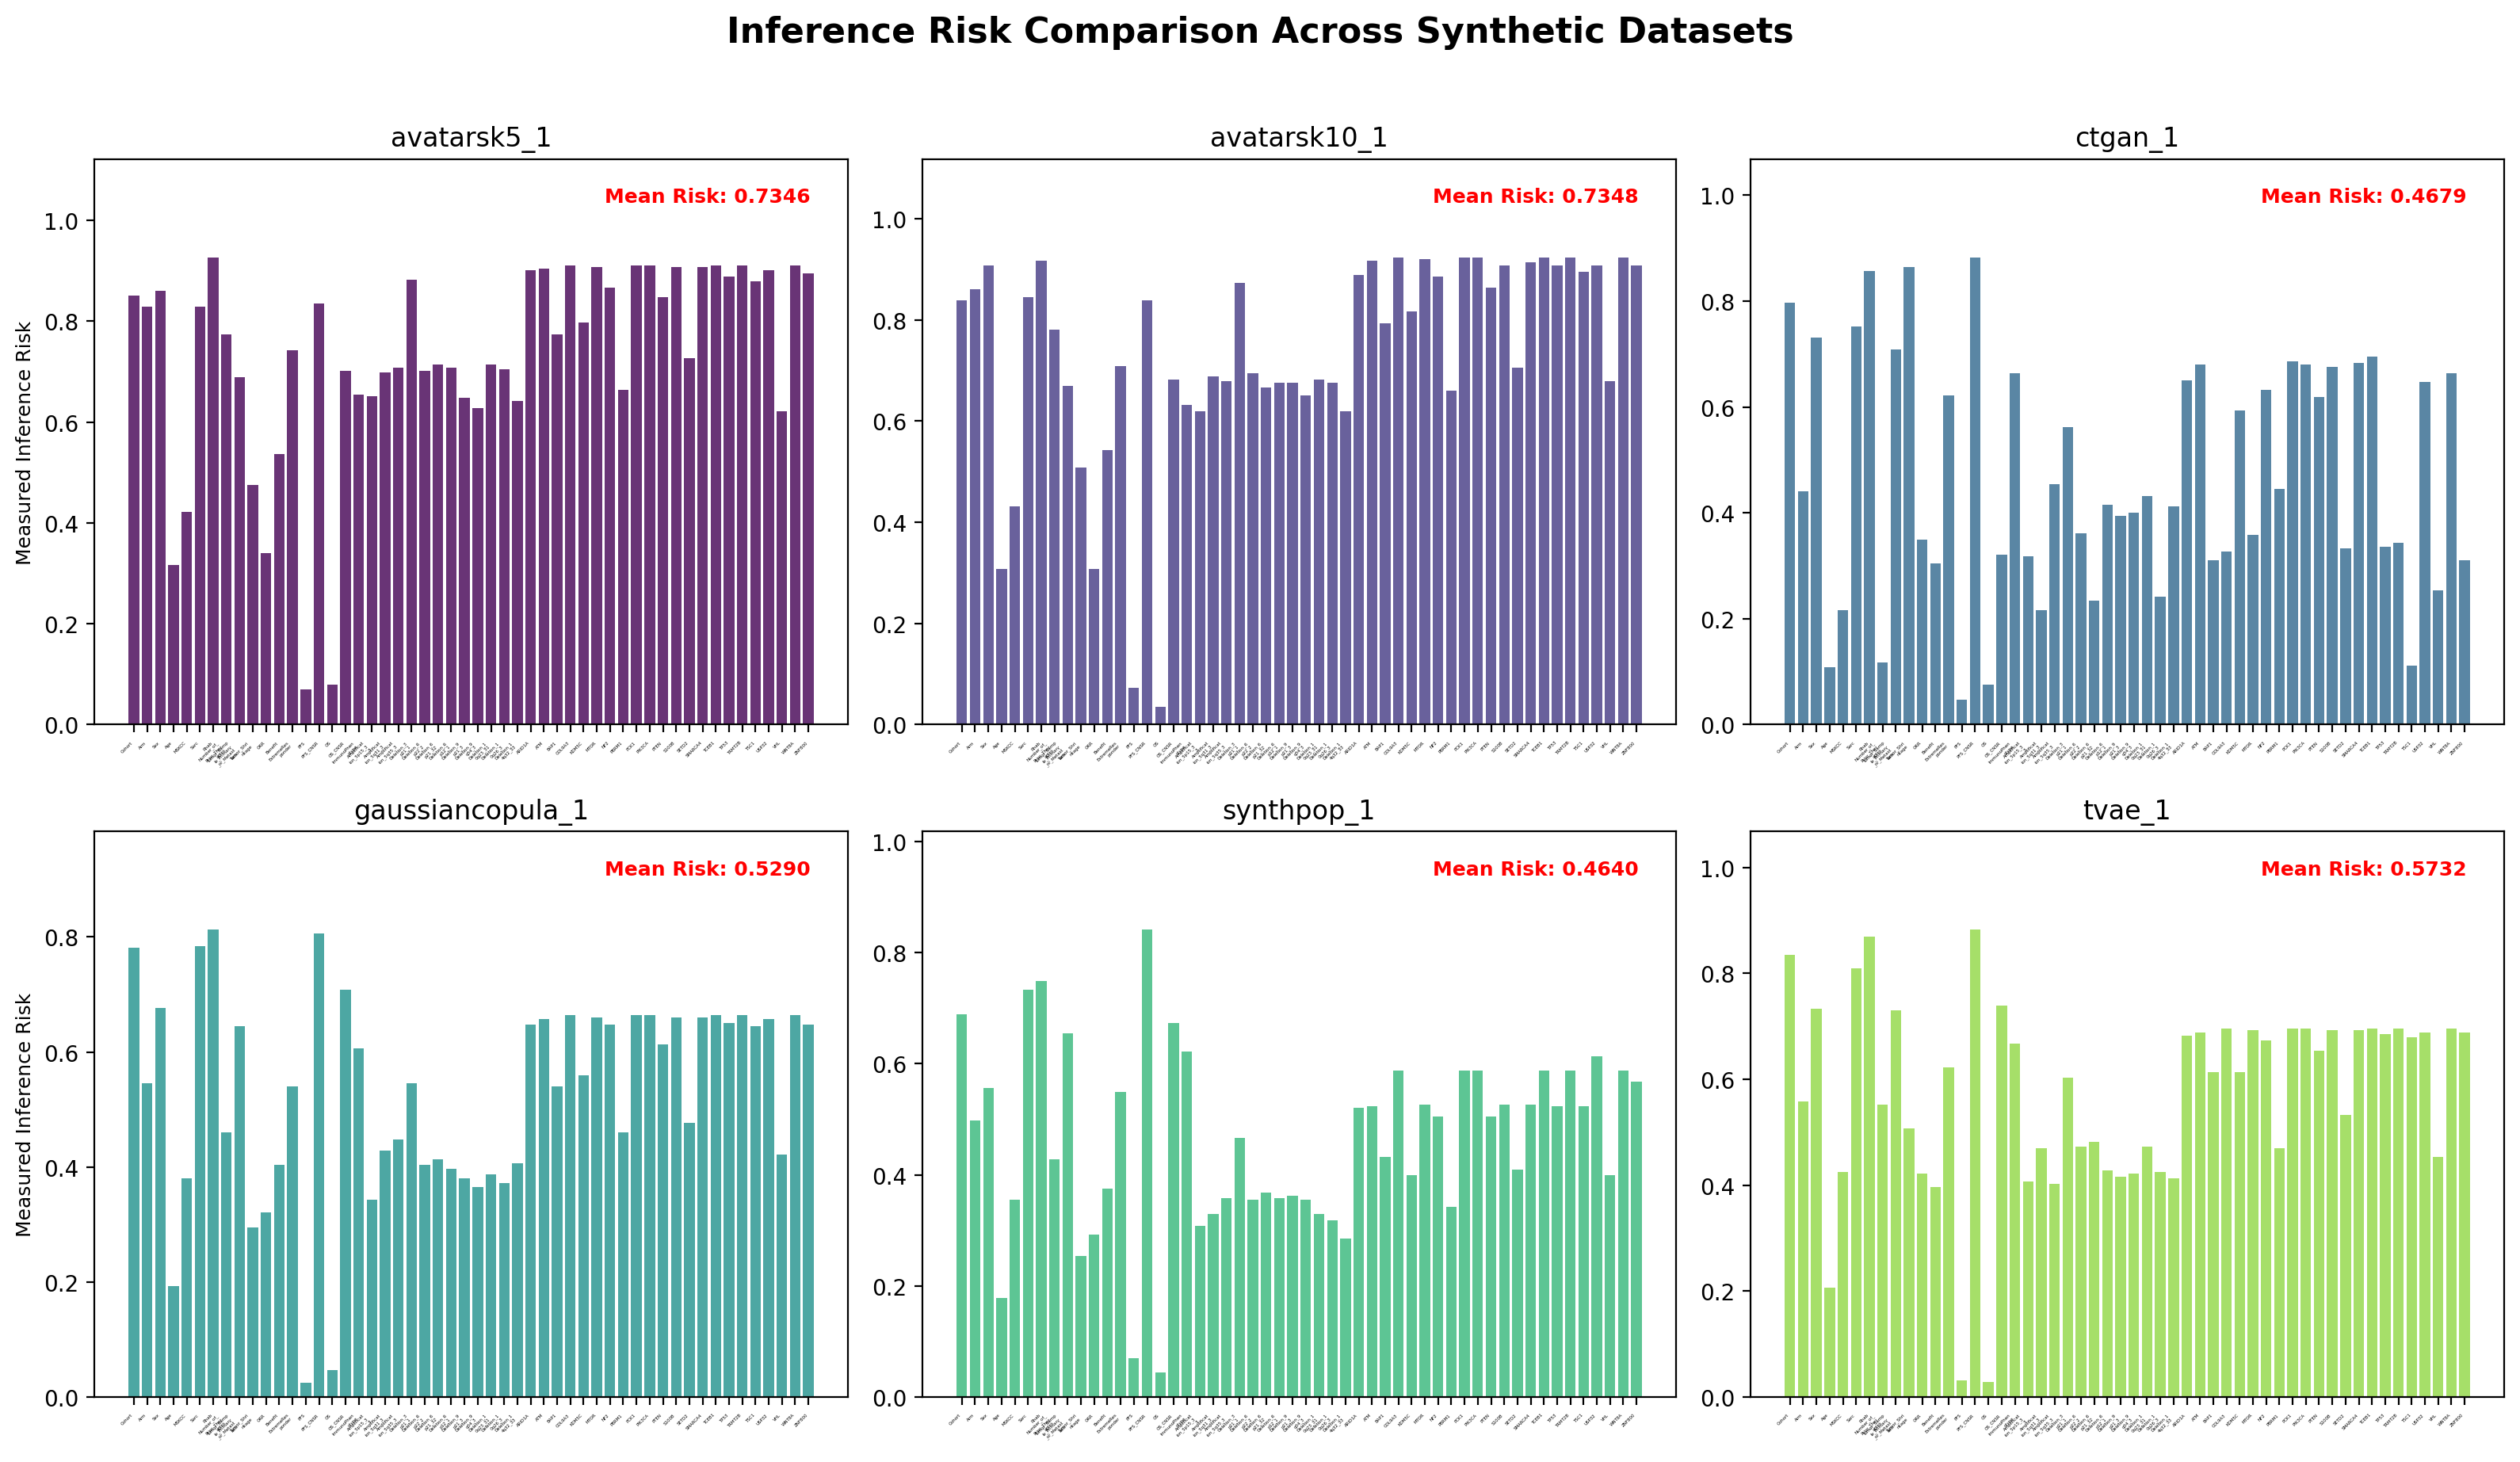

In [31]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import textwrap

seed = 1
with open(f"results_inferences_{seed}.pkl", "rb") as f:
    results_inferences = pickle.load(f)
    

# --- Subplot Configuration ---
datasets = list(results_inferences.keys())
n_datasets = len(datasets)
if n_datasets != 6:
    print(f"Warning: Expected 6 datasets, found {n_datasets}. Adjusting subplot grid.")

# Grid setup
n_rows = 2
n_cols = 3
fig_w = 16  # Overall figure width
fig_h = 9   # Overall figure height

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), dpi=200)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

alldatasets = []
for i, dataset_name in enumerate(datasets):
    # 1. Select Data
    results = results_inferences[dataset_name]
    _results = []
    for res in results:
        df = pd.DataFrame(res[1].__dict__).drop(index =1, axis = 0)
        df["Atribute"] = [res[0]]
        _results.append(df)
    df_results = pd.concat(_results, axis = 0)
    df_results["Dataset"] = [dataset_name]*(df_results.shape[0])
    alldatasets.append(df_results)
    
    risks = [res[1].risk().value for res in results]
    columns = [res[0] for res in results]
    
    # 2. Get the current subplot axis
    ax = axes[i]
    
    # 3. Calculate Mean Risk
    mean_risk = np.mean(risks)

    # 4. Prepare Labels
    wrapped = ["\n".join(textwrap.wrap(lbl, 10)) for lbl in columns] # Shorter wrap for subplots
    
    # 5. Plot Bars
    x = np.arange(len(columns))
    ax.bar(x, risks, alpha=0.8, ecolor='black', capsize=4, color=plt.cm.get_cmap('viridis')(i/n_datasets))
    
    # 6. Set Titles, Labels, and Ticks
    ax.set_title(f"{dataset_name}", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(wrapped, rotation=45, ha='right', fontsize=2)
    
    # Set Y-axis label only for the left column plots
    if i % n_cols == 0:
        ax.set_ylabel("Measured Inference Risk", fontsize=9)
    else:
        # Keep y-label clear for other plots but ensure scales are consistent (optional, depending on data)
        # ax.tick_params(labelleft=False) 
        pass 

    # 7. Add Mean Value Annotation
    # Determine annotation position (top right corner of the plot)
    y_lim_max = max(risks) * 1.1 if risks else 1.0 # Max height with 10% buffer
    x_pos = len(columns) - 1 # Position above the last bar
    
    # Set Y-limit to ensure consistency and space for annotation
    ax.set_ylim(0, y_lim_max * 1.1)
    
    # Text position: use an absolute position relative to the axes
    ax.text(0.95, 0.95, 
            f'Mean Risk: {mean_risk:.4f}', 
            transform=ax.transAxes, # Use axis coordinates (0 to 1)
            fontsize=9, 
            color='red', 
            fontweight='bold', 
            ha='right', va='top', 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    ax.grid(False)
# Remove any unused subplots if n_datasets < n_rows * n_cols
for j in range(n_datasets, n_rows * n_cols):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap, especially with rotated x-labels
plt.suptitle("Inference Risk Comparison Across Synthetic Datasets", y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 1]) 

# Save high-res copy
plt.savefig(f"inference_risk_benchmark_{seed}.png", dpi=300, bbox_inches="tight")
plt.show()

df_InferencesRisk = pd.concat(alldatasets,axis=0)
df_InferencesRisk.to_csv(f"df_InferencesRisk_{seed}.csv", index = False)

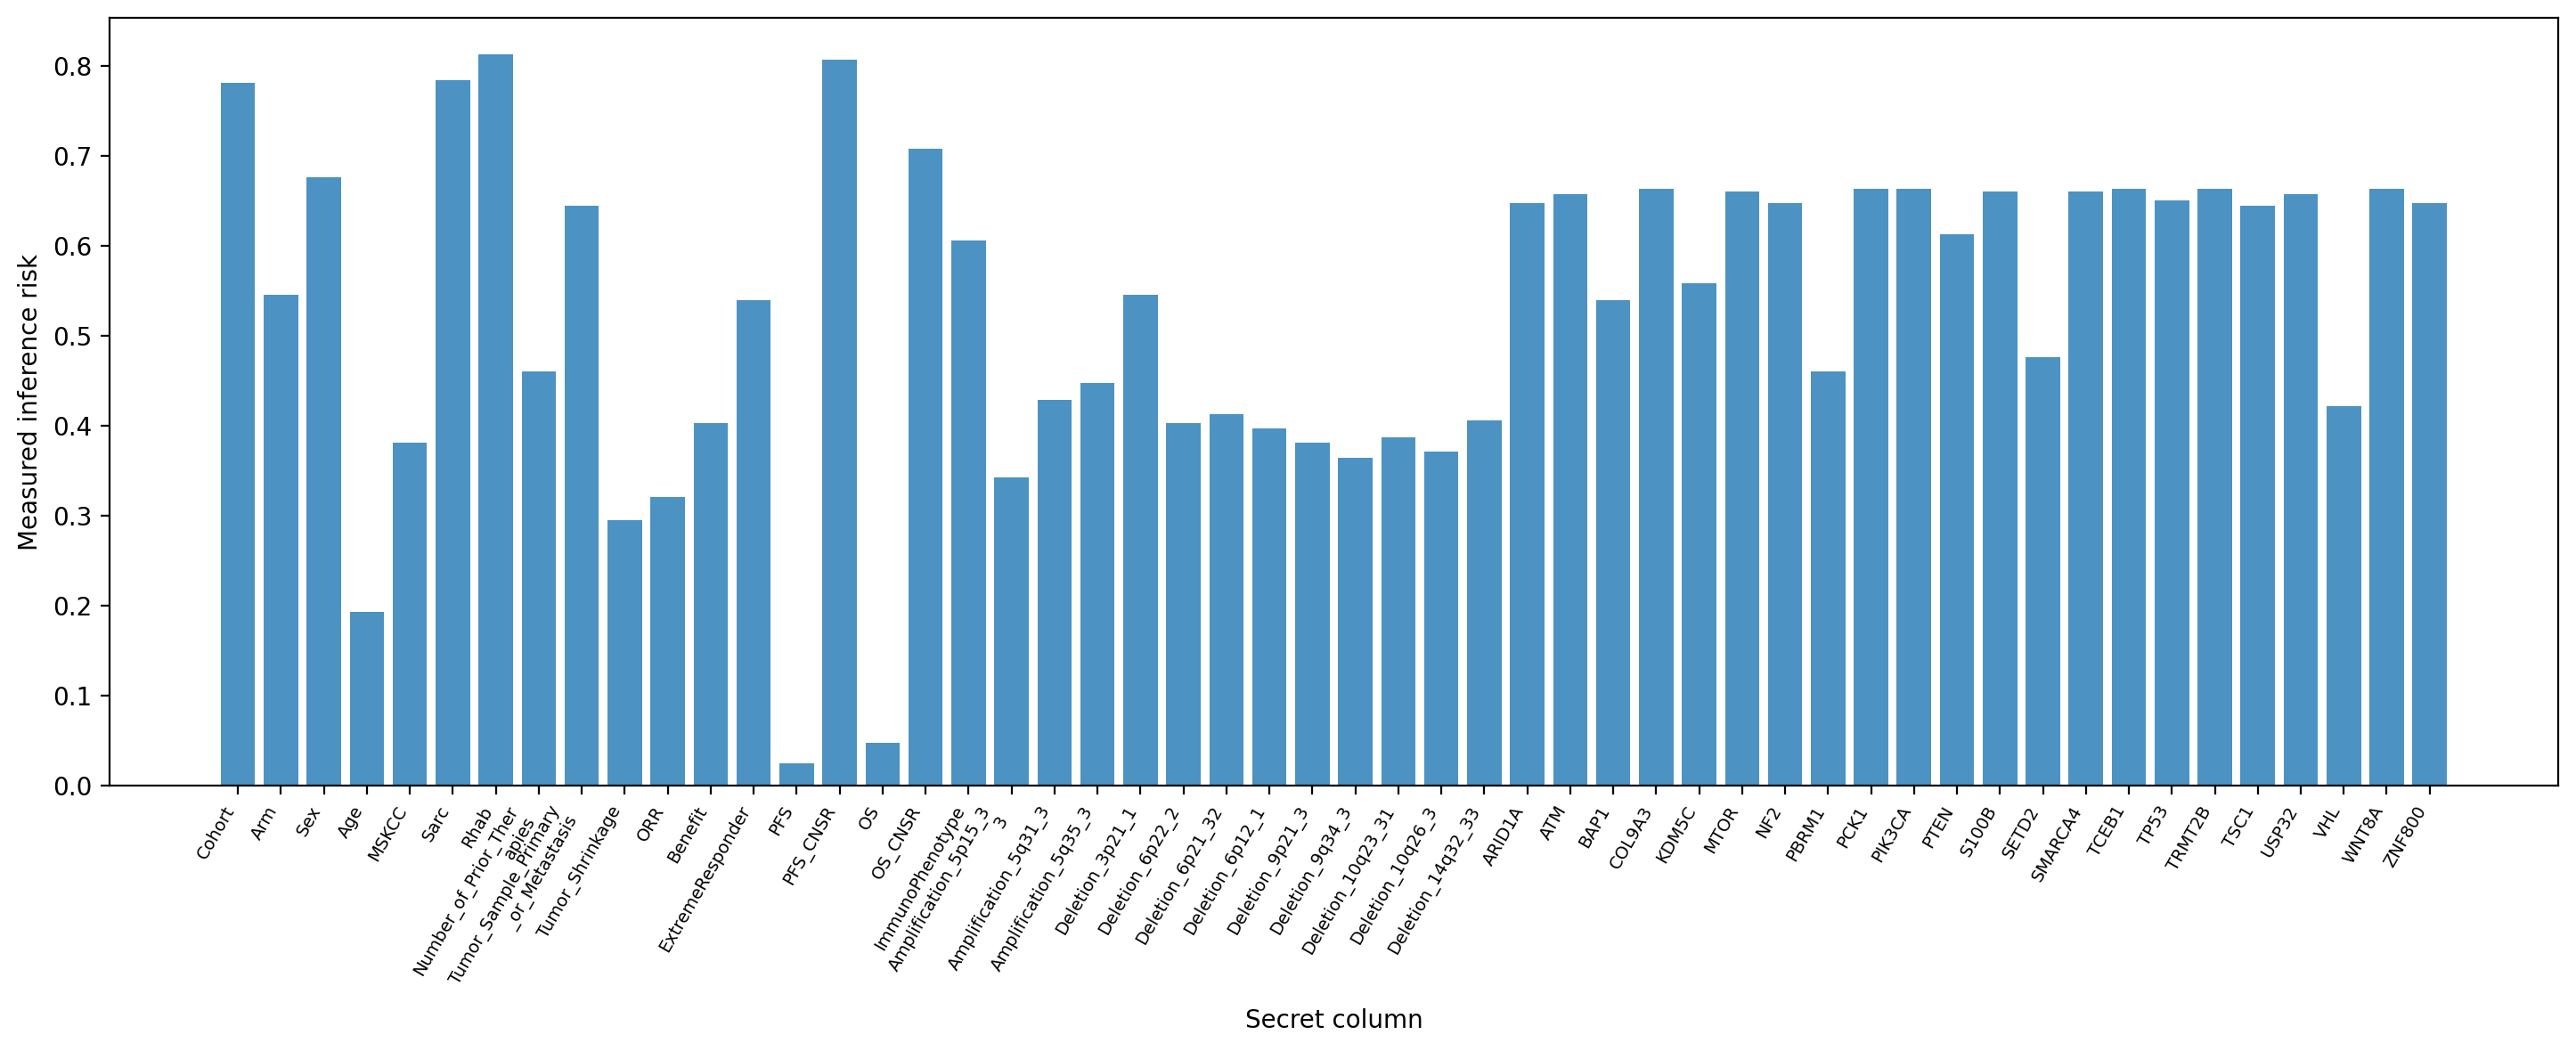

In [32]:
# data
tool = f"gaussiancopula_{seed}"
results = results_inferences[tool]
risks = [res[1].risk().value for res in results]
columns = [res[0] for res in results]

# Optional: wrap long labels so they occupy multiple lines
wrapped = [ "\n".join(textwrap.wrap(lbl, 20)) for lbl in columns ]

# Dynamic figure width: scale with number of bars
n = len(columns)
fig_w = max(10, n * 0.28)    # tweak the multiplier to taste
fig_h = 6

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=200)  # higher DPI for quality
x = np.arange(n)
ax.bar(x, risks, alpha=0.8, ecolor='black', capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(wrapped, rotation=60, ha='right', fontsize=7)
ax.set_ylabel("Measured inference risk")
ax.set_xlabel("Secret column")

plt.tight_layout()   # ensure labels are not cut off

# Save high-res copy
plt.savefig(f"InferencesRisk_{tool}.png", dpi=300, bbox_inches="tight")
plt.show()